In [1]:
from amphibian import get_data_accessor

def query(sql):
    return get_data_accessor(engines=['presto']).fetch_sql(sql=sql)

## Weekly Autoship adoption by cell, Non-Promo vs. Promo

**Plan:** `12bbfac2-30c0-4e39-860b-77240c23bb8f` (primary allocation; the QA allocation plan `7b6312fa-5fc7-4089-a4a7-e50bb82058eb` is excluded throughout). **Cell 1** = `control_autoship_no_promo` (Non-Promo Nudge) · **Cell 2** = `treatment_autoship_promo` (Promo Nudge).

Two source tables:
- `ab.current_allocations` — one row per client at allocation time, giving the authoritative allocation timestamp and cell assignment. Used here for **total allocated per cell**, cumulative through each week.
- `metrics.client_fix_autoship_unagg` — a daily snapshot table (`as_of`), giving each client's Autoship flag as of that day. Used here for **total adopted per cell**. Because this table is a same-day snapshot re-taken daily rather than a running history, weekly figures are built by keeping only the most recent `as_of` snapshot that falls within each calendar week, then aggregating.

In [2]:
PRIMARY_PLAN_ID = '12bbfac2-30c0-4e39-860b-77240c23bb8f'  # QA plan '7b6312fa-5fc7-4089-a4a7-e50bb82058eb' excluded
CELL_TO_ARM = {1: 'non_promo', 2: 'promo_10'}

### Weekly allocation volume by cell

Cumulative distinct clients allocated to each cell, as of the end of each calendar week.

In [3]:
allocation_query = f"""--sql
SELECT
    DATE_TRUNC('week', event_ts) AS week,
    cell_id,
    COUNT(DISTINCT rand_unit_value) AS n_allocated_that_week
FROM ab.current_allocations
WHERE plan_id = '{PRIMARY_PLAN_ID}'
GROUP BY 1, 2
ORDER BY 1, 2
"""

allocation_by_week_df = query(allocation_query)
allocation_by_week_df['arm'] = allocation_by_week_df['cell_id'].map(CELL_TO_ARM)
allocation_by_week_df['n_allocated_cumulative'] = (
    allocation_by_week_df.sort_values('week')
    .groupby('cell_id')['n_allocated_that_week']
    .cumsum()
)
allocation_by_week_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,week,cell_id,n_allocated_that_week,arm,n_allocated_cumulative
0,2026-08-10 00:00:00.000,1,164,non_promo,164
1,2026-08-10 00:00:00.000,2,177,promo_10,177
2,2026-08-17 00:00:00.000,1,281,non_promo,445
3,2026-08-17 00:00:00.000,2,258,promo_10,435
4,2026-08-24 00:00:00.000,1,104,non_promo,549
5,2026-08-24 00:00:00.000,2,106,promo_10,541


### Daily allocation volume by cell

Tracking this daily (not just weekly) to confirm whether a suspected system artifact suppressing allocation has actually been resolved.

In [4]:
daily_allocation_query = f"""--sql
SELECT
    DATE(event_ts) AS allocation_date,
    COUNT(DISTINCT CASE WHEN cell_id = 1 THEN rand_unit_value END) AS n_control,
    COUNT(DISTINCT CASE WHEN cell_id = 2 THEN rand_unit_value END) AS n_treatment,
    COUNT(DISTINCT rand_unit_value) AS n_total,
    ROUND(CAST(COUNT(DISTINCT CASE WHEN cell_id = 2 THEN rand_unit_value END) AS DOUBLE) / NULLIF(COUNT(DISTINCT rand_unit_value), 0), 3) AS pct_treatment
FROM ab.current_allocations
WHERE plan_id = '{PRIMARY_PLAN_ID}'
GROUP BY 1
ORDER BY 1
"""

daily_allocation_df = query(daily_allocation_query)
daily_allocation_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,allocation_date,n_control,n_treatment,n_total,pct_treatment
0,2026-08-12,8,16,24,0.667
1,2026-08-13,40,46,86,0.535
2,2026-08-14,40,40,80,0.500
3,2026-08-15,36,44,80,0.550
4,2026-08-16,40,31,71,0.437
5,2026-08-17,34,32,66,0.485
6,2026-08-18,26,31,57,0.544
7,2026-08-19,37,29,66,0.439
8,2026-08-20,39,36,75,0.480
9,2026-08-21,56,50,106,0.472


### Weekly Autoship adoption by cell

For each calendar week, this takes the most recent `as_of` snapshot available within that week (so a week still in progress is read as "as of its latest snapshot so far," not a complete week), and sums `autoship_flag_at_end` per cell.

In [5]:
adoption_query = f"""--sql
WITH weekly_snapshots AS (
    SELECT
        DATE_TRUNC('week', DATE_PARSE(as_of, '%Y%m%d')) AS week,
        as_of,
        client_id,
        cell_id,
        COALESCE(MAX_BY(autoship_flag, client_record_sequence), 0) AS autoship_flag_at_end
    FROM metrics.client_fix_autoship_unagg
    WHERE plan_id = '{PRIMARY_PLAN_ID}'
    GROUP BY as_of, client_id, cell_id
),
latest_per_week AS (
    SELECT week, client_id, cell_id, autoship_flag_at_end,
           ROW_NUMBER() OVER (PARTITION BY week, client_id ORDER BY as_of DESC) AS rn
    FROM weekly_snapshots
)
SELECT
    week,
    cell_id,
    COUNT(DISTINCT client_id) AS n_clients_in_metrics_table,
    SUM(autoship_flag_at_end) AS n_adopted
FROM latest_per_week
WHERE rn = 1
GROUP BY week, cell_id
ORDER BY week, cell_id
"""

adoption_by_week_df = query(adoption_query)
adoption_by_week_df['arm'] = adoption_by_week_df['cell_id'].map(CELL_TO_ARM)
adoption_by_week_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,week,cell_id,n_clients_in_metrics_table,n_adopted,arm
0,2026-08-10 00:00:00.000,1,164,59,non_promo
1,2026-08-10 00:00:00.000,2,177,63,promo_10
2,2026-08-17 00:00:00.000,1,445,138,non_promo
3,2026-08-17 00:00:00.000,2,435,155,promo_10
4,2026-08-24 00:00:00.000,1,530,168,non_promo
5,2026-08-24 00:00:00.000,2,518,180,promo_10


### Combined weekly summary: total Autoship adoption, Non-Promo vs. Promo

Joins the two views above: `n_allocated_cumulative` from `ab.current_allocations` (total clients ever allocated to that cell, through that week) against `n_adopted` from the metrics snapshot table. `n_clients_in_metrics_table` is shown alongside `n_allocated_cumulative` as a completeness check — the two should track closely; a persistent gap would mean the metrics pipeline is lagging behind actual allocation.

In [6]:
summary_df = allocation_by_week_df.merge(
    adoption_by_week_df[['week', 'cell_id', 'n_clients_in_metrics_table', 'n_adopted']],
    on=['week', 'cell_id'], how='left'
)
summary_df['adoption_rate'] = summary_df['n_adopted'] / summary_df['n_allocated_cumulative']
summary_df = summary_df[['week', 'arm', 'n_allocated_cumulative', 'n_clients_in_metrics_table', 'n_adopted', 'adoption_rate']]
summary_df.sort_values(['week', 'arm']).reset_index(drop=True)

,week,arm,n_allocated_cumulative,n_clients_in_metrics_table,n_adopted,adoption_rate
0,2026-08-10 00:00:00.000,non_promo,164,164,59,0.359756
1,2026-08-10 00:00:00.000,promo_10,177,177,63,0.355932
2,2026-08-17 00:00:00.000,non_promo,445,445,138,0.310112
3,2026-08-17 00:00:00.000,promo_10,435,435,155,0.356322
4,2026-08-24 00:00:00.000,non_promo,549,530,168,0.306011
5,2026-08-24 00:00:00.000,promo_10,541,518,180,0.332717


### Side-by-side: Promo vs. Non-Promo, per week

Pivoted view for a direct read on each experience's contribution to overall adoption.

In [7]:
pivot_df = summary_df.pivot(index='week', columns='arm', values=['n_allocated_cumulative', 'n_adopted', 'adoption_rate'])
pivot_df

n_allocated_cumulative          n_adopted           \
arm                                  non_promo promo_10 non_promo promo_10   
week                                                                         
2026-08-10 00:00:00.000                  164.0    177.0      59.0     63.0   
2026-08-17 00:00:00.000                  445.0    435.0     138.0    155.0   
2026-08-24 00:00:00.000                  549.0    541.0     168.0    180.0   

                        adoption_rate            
arm                         non_promo  promo_10  
week                                             
2026-08-10 00:00:00.000      0.359756  0.355932  
2026-08-17 00:00:00.000      0.310112  0.356322  
2026-08-24 00:00:00.000      0.306011  0.332717

### Chart: weekly Autoship adoption rate, Non-Promo vs. Promo

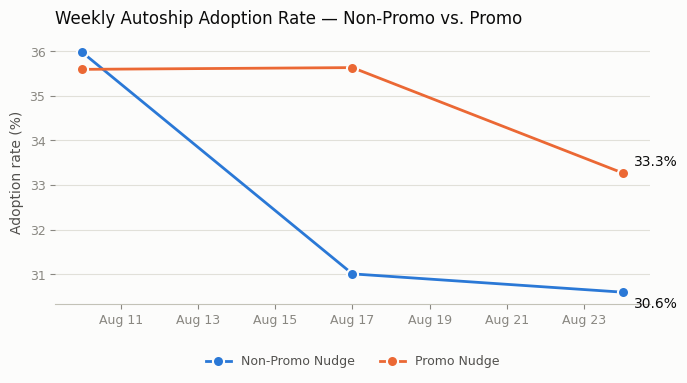

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

COLOR_NON_PROMO = "#2a78d6"  # categorical slot 1 (blue)
COLOR_PROMO = "#eb6834"      # categorical slot 2 (orange)
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

chart_df = summary_df.copy()
chart_df["week"] = pd.to_datetime(chart_df["week"])

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

label_y_nudge = {"non_promo": -8, "promo_10": 8}  # dodge end labels apart when lines converge

for arm, color in [("non_promo", COLOR_NON_PROMO), ("promo_10", COLOR_PROMO)]:
    s = chart_df[chart_df["arm"] == arm].sort_values("week")
    ax.plot(
        s["week"], s["adoption_rate"] * 100,
        color=color, linewidth=2, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor="#fcfcfb", markeredgewidth=1.5,
        label="Non-Promo Nudge" if arm == "non_promo" else "Promo Nudge",
    )
    last = s.iloc[-1]
    ax.annotate(
        f"{last['adoption_rate']*100:.1f}%",
        xy=(last["week"], last["adoption_rate"] * 100),
        xytext=(8, label_y_nudge[arm]), textcoords="offset points",
        va="center", color="#0b0b0b", fontsize=10, fontweight="medium",
    )

ax.set_title("Weekly Autoship Adoption Rate — Non-Promo vs. Promo", color="#0b0b0b", fontsize=12, pad=12, loc="left")
ax.set_ylabel("Adoption rate (%)", color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.tick_params(axis="both", colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)

ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, labelcolor=INK_SECONDARY)

plt.tight_layout()
plt.show()